<a href="https://colab.research.google.com/github/quiggiu/human-activity-recognition-classifier/blob/main/human_activity_recognition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Carica le librerie necessarie.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sklearn as sk

from collections import Counter
from sklearn.preprocessing import StandardScaler

Download del dataset.

In [2]:
import os

if not os.path.exists('UCI HAR Dataset'):
    # Scarica lo .zip dal repository ufficiale
    print("Scaricamento del dataset in corso...")
    !wget -q "https://archive.ics.uci.edu/ml/machine-learning-databases/00240/UCI%20HAR%20Dataset.zip"
    # Decomprime il file
    !unzip -q "UCI HAR Dataset.zip"
    print("Operazione completata!")
else:
    print("Dataset già presente in questo ambiente.")

Scaricamento del dataset in corso...
Operazione completata!


Caricamento dei nomi delle features,correzione dei nomi duplicati (in alcune mancano gli assi di riferimento) e caricamento del train e test (70-30) già forniti dal dataset.

In [3]:
base_path= 'UCI HAR Dataset/'

# Carica i nomi delle features
features= pd.read_csv(f'{base_path}features.txt', sep=r'\s+', header=None, names=['index', 'feature_name'])
feature_names= features['feature_name'].tolist()


# Conta tutte le feature per sapere in anticipo quali hanno duplicati
conteggi= Counter(feature_names)
clean_feature_names= []
visti= {}
assi= ['X', 'Y', 'Z']

for nome in feature_names:
    if conteggi[nome] > 1:
        # Se la colonna ha duplicati, inizializziamo il contatore e prendiamo la lettera
        visti[nome]= visti.get(nome, 0)
        clean_feature_names.append(f"{nome}-{assi[visti[nome]]}")
        visti[nome]+= 1
    else:
        clean_feature_names.append(nome)

# Visualizza i nomi di tutte le features
#pd.DataFrame({'Features': clean_feature_names})

# Check per valori nulli
#print(X_train.isna().values.any())

# Carica i file di addestramento e di validazione
X_train= pd.read_csv(f'{base_path}train/X_train.txt', sep=r'\s+', header=None, names=clean_feature_names)
y_train= pd.read_csv(f'{base_path}train/y_train.txt', sep=r'\s+', header=None, names=['Activity_Label'])
subject_train= pd.read_csv(f'{base_path}train/subject_train.txt', sep=r'\s+', header=None, names=['Subject_ID'])

X_test= pd.read_csv(f'{base_path}test/X_test.txt', sep=r'\s+', header=None, names=clean_feature_names)
y_test= pd.read_csv(f'{base_path}test/y_test.txt', sep=r'\s+', header=None, names=['Activity_Label'])
subject_test= pd.read_csv(f'{base_path}test/subject_test.txt', sep=r'\s+', header=None, names=['Subject_ID'])

X_train.head()

,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-meanFreq(),fBodyBodyGyroJerkMag-skewness(),fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)"
0,0.288585,-0.020294,-0.132905,-0.995279,-0.983111,-0.913526,-0.995112,-0.983185,-0.923527,-0.934724,...,-0.074323,-0.298676,-0.710304,-0.112754,0.030400,-0.464761,-0.018446,-0.841247,0.179941,-0.058627
1,0.278419,-0.016411,-0.123520,-0.998245,-0.975300,-0.960322,-0.998807,-0.974914,-0.957686,-0.943068,...,0.158075,-0.595051,-0.861499,0.053477,-0.007435,-0.732626,0.703511,-0.844788,0.180289,-0.054317
2,0.279653,-0.019467,-0.113462,-0.995380,-0.967187,-0.978944,-0.996520,-0.963668,-0.977469,-0.938692,...,0.414503,-0.390748,-0.760104,-0.118559,0.177899,0.100699,0.808529,-0.848933,0.180637,-0.049118
3,0.279174,-0.026201,-0.123283,-0.996091,-0.983403,-0.990675,-0.997099,-0.982750,-0.989302,-0.938692,...,0.404573,-0.117290,-0.482845,-0.036788,-0.012892,0.640011,-0.485366,-0.848649,0.181935,-0.047663
4,0.276629,-0.016570,-0.115362,-0.998139,-0.980817,-0.990482,-0.998321,-0.979672,-0.990441,-0.942469,...,0.087753,-0.351471,-0.699205,0.123320,0.122542,0.693578,-0.615971,-0.847865,0.185151,-0.043892


,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-meanFreq(),fBodyBodyGyroJerkMag-skewness(),fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)"
count,2947.000000,2947.000000,2947.000000,2947.000000,2947.000000,2947.000000,2947.000000,2947.000000,2947.000000,2947.000000,...,2947.000000,2947.000000,2947.000000,2947.000000,2947.000000,2947.000000,2947.000000,2947.000000,2947.000000,2947.000000
mean,0.273996,-0.017863,-0.108386,-0.613635,-0.508330,-0.633797,-0.641278,-0.522676,-0.637038,-0.462063,...,0.130236,-0.277593,-0.598756,0.005264,0.003799,0.040029,-0.017298,-0.513923,0.074886,-0.048720
std,0.060570,0.025745,0.042747,0.412597,0.494269,0.362699,0.385199,0.479899,0.357753,0.523916,...,0.231018,0.317245,0.311042,0.336147,0.445077,0.634989,0.501311,0.509205,0.324300,0.241467
min,-0.592004,-0.362884,-0.576184,-0.999606,-1.000000,-0.998955,-0.999417,-0.999914,-0.998899,-0.952357,...,-0.785543,-1.000000,-1.000000,-1.000000,-0.993402,-0.998898,-0.991096,-0.984195,-0.913704,-0.949228
25%,0.262075,-0.024961,-0.121162,-0.990914,-0.973664,-0.976122,-0.992333,-0.974131,-0.975352,-0.934447,...,-0.008433,-0.517494,-0.829593,-0.130541,-0.282600,-0.518924,-0.428375,-0.829722,0.022140,-0.098485
50%,0.277113,-0.016967,-0.108458,-0.931214,-0.790972,-0.827534,-0.937664,-0.799907,-0.817005,-0.852659,...,0.142676,-0.311023,-0.683672,0.005188,0.006767,0.047113,-0.026726,-0.729648,0.181563,-0.010671
75%,0.288097,-0.010143,-0.097123,-0.267395,-0.105919,-0.311432,-0.321719,-0.133488,-0.322771,-0.009965,...,0.288320,-0.083559,-0.458332,0.146200,0.288113,0.622151,0.394387,-0.545939,0.260252,0.092373
max,0.671887,0.246106,0.494114,0.465299,1.000000,0.489703,0.439657,1.000000,0.427958,0.786436,...,1.000000,1.000000,1.000000,0.998898,0.986347,1.000000,1.000000,0.833180,1.000000,0.973113


In [5]:

# Inizializza lo scaler per rendere le features a media nulla e varianza unitaria
scaler= StandardScaler()

X_train_normalizzato= scaler.fit_transform(X_train)
X_test_normalizzato= scaler.transform(X_test)


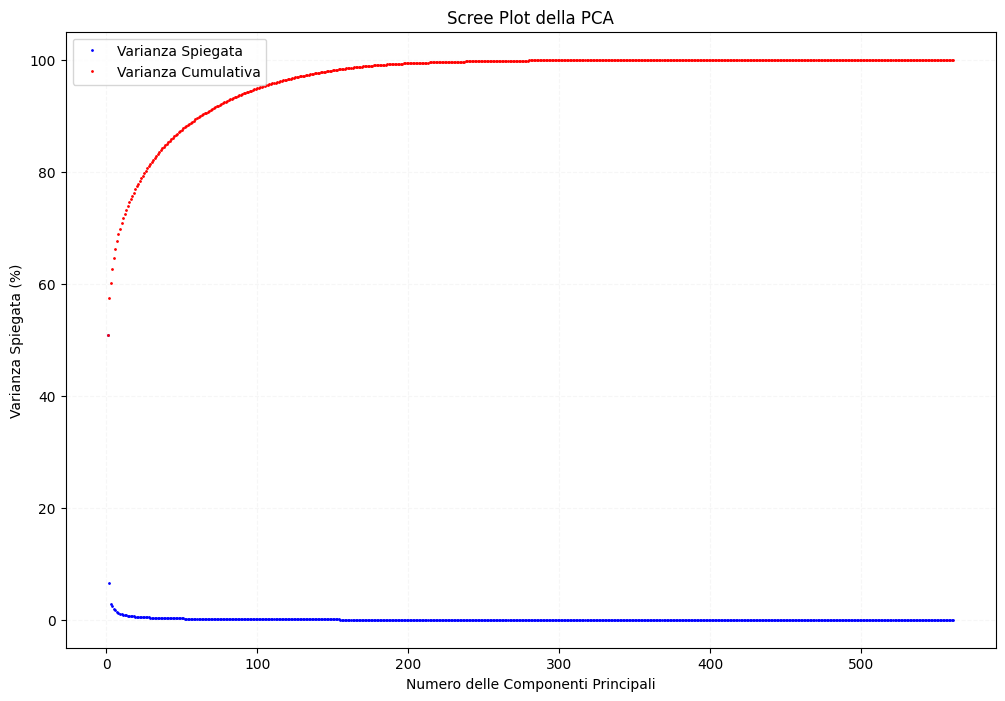


 Numero di componenti necessarie per spiegare il 90% della varianza: 63


In [6]:
from sklearn.decomposition import PCA
# Inizializza la pca
pca=PCA()
pca.fit(X_train_normalizzato)

varianza_spiegata= pca.explained_variance_ratio_*100
varianza_cumulativa=np.cumsum(varianza_spiegata)

#Plot
plt.figure(figsize=(12, 8))
plt.plot(range(1, len(varianza_spiegata) + 1), varianza_spiegata,
        linestyle="None",color='b',marker="o",label='Varianza Spiegata',markersize=1)
plt.plot(range(1, len(varianza_spiegata) + 1), varianza_cumulativa,
        linestyle="None",color='r',marker="o",label='Varianza Cumulativa',markersize=1)
plt.title('Scree Plot della PCA')
plt.xlabel('Numero delle Componenti Principali')
plt.ylabel('Varianza Spiegata (%)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.1)
plt.show()

indice = (varianza_cumulativa >= 90).argmax()
numero_componenti= indice+1

print(f"\n Numero di componenti necessarie per spiegare il 90% della varianza: {numero_componenti}")

In [7]:
# 1. Inizializzazione del modello specificando il numero di componenti k
pca_n= PCA(n_components=numero_componenti)

# 2. Calcolo dei pesi e proiezione del dataset in un solo passaggio
X_train_ridotto= pca_n.fit_transform(X_train_normalizzato)
X_test_ridotto= pca_n.transform(X_test_normalizzato)


In [8]:
from sklearn.svm import SVC
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Definizione degli iperparametri da esplorare
C_values = [0.1, 1, 10, 100]
kernel_values = ['linear', 'rbf']

# Impostazione della K-Fold Cross-Validation (5 split)
n_splits = 5
kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

# Variabili per tracciare il modello migliore
best_score = 0
best_params = {}

for kernel in kernel_values:
    for C in C_values:
        fold_scores = []

        # Iterazione sui fold creati da KFold
        for train_idx, val_idx in kf.split(X_train_ridotto):
            # Split effettivo dei dati
            X_fold_train, X_fold_val = X_train_ridotto[train_idx],X_train_ridotto[val_idx]
            y_fold_train, y_fold_val = np.array(y_train).ravel()[train_idx], np.array(y_train).ravel()[val_idx]

            # Inizializzazione della SVM con i parametri correnti
            model = SVC(C=C, kernel=kernel, gamma='scale')

            # Addestramento sul sub-training set
            model.fit(X_fold_train, y_fold_train)

            # Predizione e valutazione sul validation fold
            y_pred_val = model.predict(X_fold_val)
            score = accuracy_score(y_fold_val, y_pred_val)
            fold_scores.append(score)

        # Calcolo della performance media per la combinazione corrente
        avg_score = np.mean(fold_scores)
        print(f"Kernel: {kernel:<8} | C: {C:<5} -> Accuracy Media: {avg_score:.4f}")

        # Aggiornamento dei parametri migliori se lo score supera il precedente
        if avg_score > best_score:
            best_score = avg_score
            best_params = {'C': C, 'kernel': kernel}

print(f"\nMigliori iperparametri trovati: {best_params} con Accuracy: {best_score:.4f}")

Kernel: linear   | C: 0.1   -> Accuracy Media: 0.9559
Kernel: linear   | C: 1     -> Accuracy Media: 0.9576
Kernel: linear   | C: 10    -> Accuracy Media: 0.9565
Kernel: linear   | C: 100   -> Accuracy Media: 0.9569
Kernel: rbf      | C: 0.1   -> Accuracy Media: 0.9176
Kernel: rbf      | C: 1     -> Accuracy Media: 0.9578
Kernel: rbf      | C: 10    -> Accuracy Media: 0.9693
Kernel: rbf      | C: 100   -> Accuracy Media: 0.9712

Migliori iperparametri trovati: {'C': 100, 'kernel': 'rbf'} con Accuracy: 0.9712


In [12]:
# Inizializzazione con i parametri ottimali
final_model = SVC(C=best_params['C'], kernel=best_params['kernel'], gamma='scale')

# Addestramento sull'intero dataset di training normalizzato
final_model.fit(X_train_ridotto, y_train)

# Predizione sui dati di test blind
y_test_pred = final_model.predict(X_test_ridotto)

print("\n--- Risultati sul Test Set ---")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_test_pred))

print("\nClassification Report:")
# Il report mostra Precision, Recall, F1-Score e Support
print(classification_report(y_test, y_test_pred))

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)



--- Risultati sul Test Set ---

Confusion Matrix:
[[471  17   8   0   0   0]
 [ 31 427  13   0   0   0]
 [ 12  40 368   0   0   0]
 [  0   0   0 427  62   2]
 [  0   0   0  48 484   0]
 [  0   0   0  18   1 518]]

Classification Report:
              precision    recall  f1-score   support

           1       0.92      0.95      0.93       496
           2       0.88      0.91      0.89       471
           3       0.95      0.88      0.91       420
           4       0.87      0.87      0.87       491
           5       0.88      0.91      0.90       532
           6       1.00      0.96      0.98       537

    accuracy                           0.91      2947
   macro avg       0.92      0.91      0.91      2947
weighted avg       0.92      0.91      0.91      2947

